In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv


### Title & Introduction
Exploratory Data Analysis of a Retail Sales Dataset

## Objective:
-Analyze retail sales data to identify sales trends, customer behavior, product performance and provide actionable business recommendations

Import Libraries:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv")
print(df.info())
print(df.shape)
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
(1000, 9)
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023

In [4]:
print(df.isnull().sum())
print(df.describe())
print(df.duplicated().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000
0


Initial Inspection:
The dataset contains 1000 rows and 9 columns. No missing values or duplicates were found, but the date column appears to be in the wrong format and hence need to be changed.

In [5]:
#Fix data types
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)
print(df.dtypes)

#Extract Month and Quater for time series:
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year
print("Cleaned")
print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object
Cleaned
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Month                        int32
Month_Name                  object
Quarter                      int32
Year                         int32
dtype: object


/tmp/ipykernel_16/2923957420.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)


In [6]:
numerical = df.select_dtypes(include=np.number)
stats =pd.DataFrame({
    "mean": numerical.mean(),
    "median": numerical.median(),
    "mode": numerical.mode().iloc[0],
    "Standard Deviation": numerical.std()
})
print(stats)

                    mean  median    mode  Standard Deviation
Transaction ID   500.500   500.5     1.0          288.819436
Age               41.392    42.0    43.0           13.681430
Quantity           2.514     3.0     4.0            1.132734
Price per Unit   179.890    50.0    50.0          189.681356
Total Amount     456.000   135.0    50.0          559.997632
Month              6.549     6.0     5.0            3.452755
Quarter            2.525     2.0     2.0            1.119208
Year            2023.002  2023.0  2023.0            0.044699


Descriptive Statistics:

Key Observations from the summary statistics:
-Average customer age is around 41(mean) years suggesting the core customers are adults
-Average purchase quantity per transaction is 4 units(mode)
-Average transaction value is 135(median)
-Standard deviation in Total Amount is $599.99 significantly higher than what woud be expected for a uniform customer base. This high variability suggests distinct customer spending spending segments exists within the dataset, presenting an opportunity for targetted marketing and customer segmentation strategies.

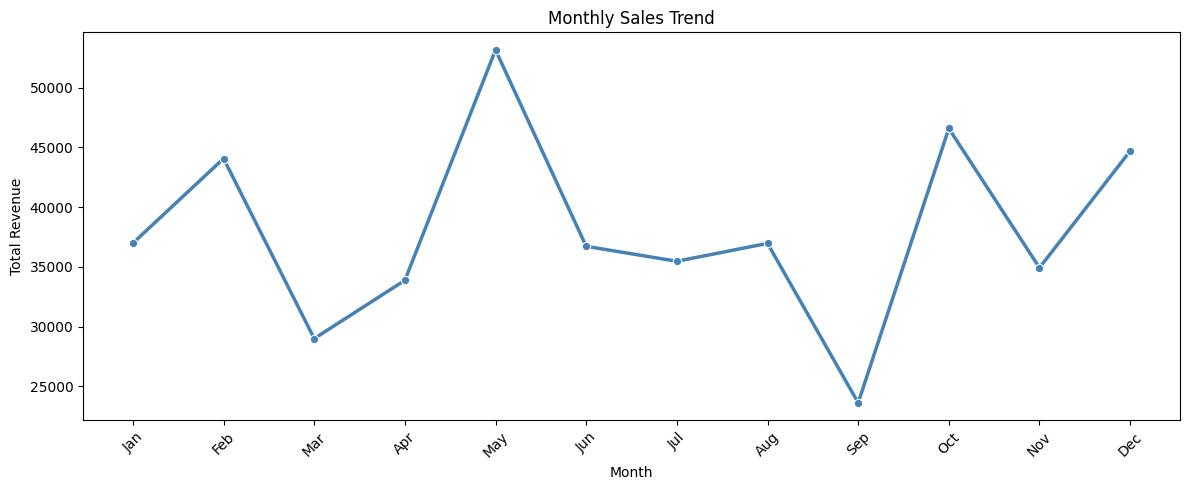

In [7]:
#Monthly Sales Trend
monthly_sales = df.groupby(df['Month'])['Total Amount'].sum().reset_index()
monthly_sales['Month_Name'] = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='Month_Name', y='Total Amount',marker='o',color='steelblue',lw=2.5)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Monthly sales trend shows we started the financial year strongly with a steady rising in the month of january followed by an abrupt decline in the months of febuary an march. Our all time high was in the month of May with total revenue exceeding $50,000 suggesting possible seasonal demand or promotional activity. That high was succeeded not immediately though by an all time low in the month of september before picking up again.

   Quarter  Total Amount Quarter_Name
0        1        110030           Q1
1        2        123735           Q2
2        3         96045           Q3
3        4        126190           Q4


/tmp/ipykernel_16/698633028.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quarterly_sales, x='Quarter_Name', y='Total Amount', palette='Blues_d')


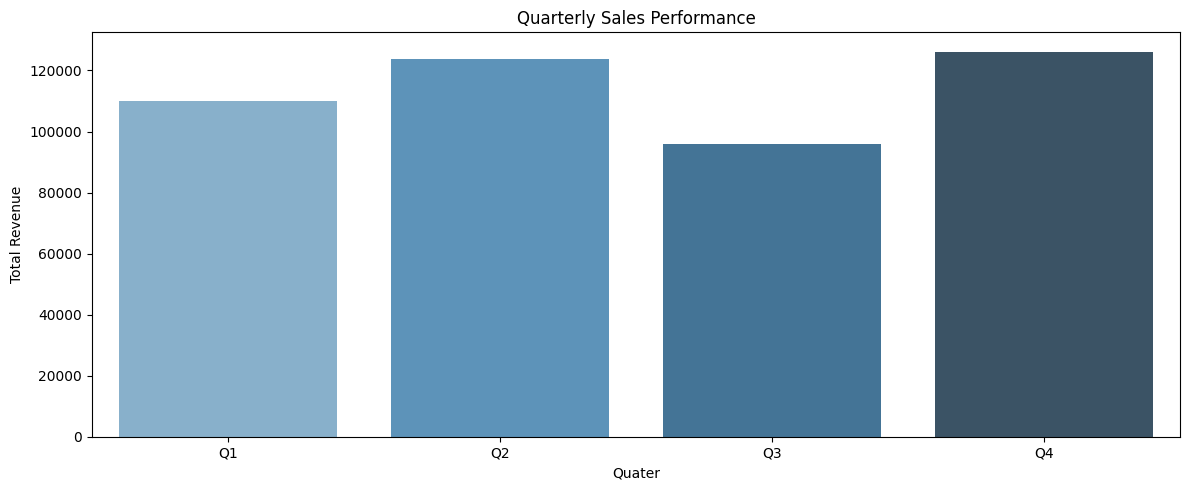

In [8]:
#Quarterly Sales Trend
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum().reset_index()
quarterly_sales['Quarter_Name'] = ['Q1','Q2','Q3','Q4']
print(quarterly_sales)

plt.figure(figsize=(12,5))
sns.barplot(data=quarterly_sales, x='Quarter_Name', y='Total Amount', palette='Blues_d')
plt.title('Quarterly Sales Performance')
plt.xlabel("Quater")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

 Quarterly breakdown reveals Q4 as the highest performing quarter with 126,190 in revenue while Q3 was the lowest 96,045 in revenue

/tmp/ipykernel_16/2538464912.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values,palette='viridis')


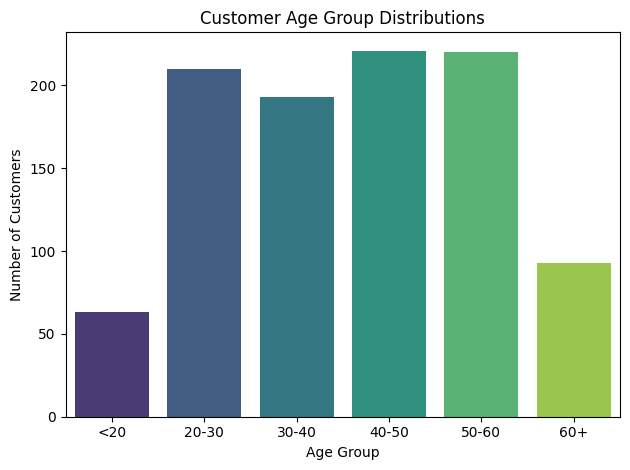

In [9]:
#Customer Age Distribution
bins = [0,20,30,40,50,60,100]
labels = ['<20','20-30','30-40','40-50','50-60','60+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_counts = df['Age Group'].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values,palette='viridis')
plt.title("Customer Age Group Distributions")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

The age distribution shows that the majority of our customers age between 40-50 years followed by 50-60, 20-30, 30-40, 60+ and the least being <20.

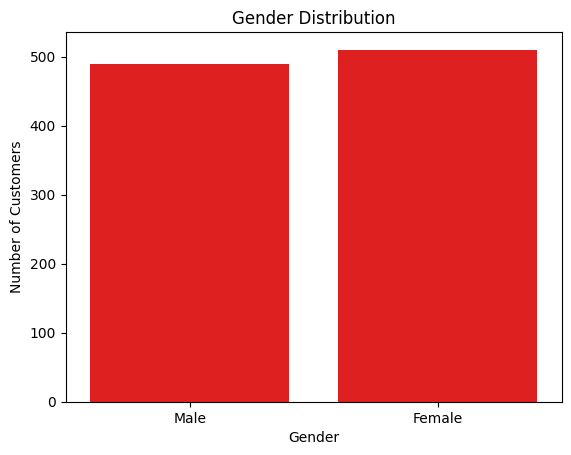

Gender
Female    510
Male      490
Name: count, dtype: int64


In [10]:
#Gender Distribution
sns.countplot(data=df, x="Gender",color='red')
plt.title("Gender Distribution")
plt.ylabel("Number of Customers")
plt.show()
print(df['Gender'].value_counts())

Gender Distribution shows most of our customers are female with a whopping 510 in population as opposed to the 490 male count

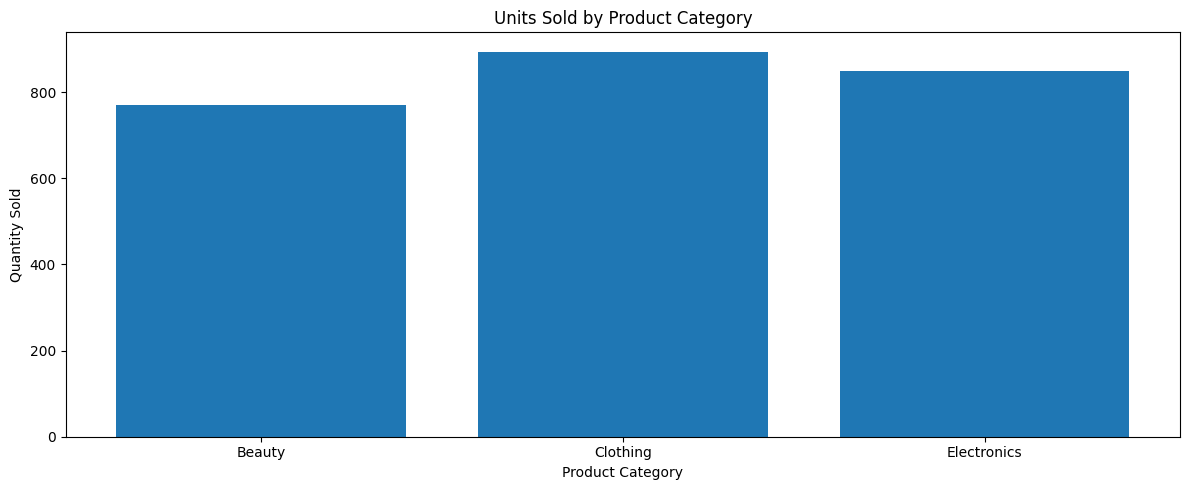

In [11]:
#Top products category by units sold

plt.figure(figsize=(12,5))
top_categories = df.groupby('Product Category')['Quantity'].sum()
plt.bar(top_categories.index, top_categories.values)
plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")

plt.tight_layout()
plt.show()

Clothing is most purchased followed by Electronics and the beauty being the least

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


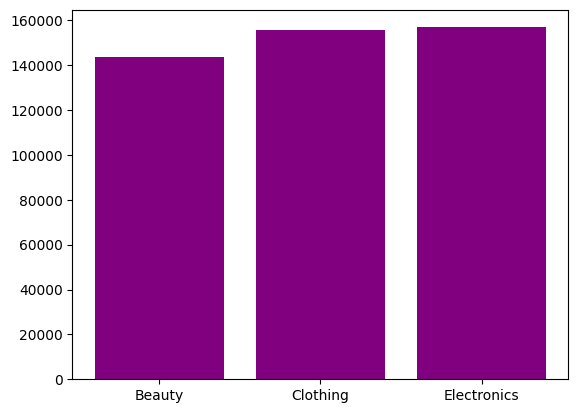

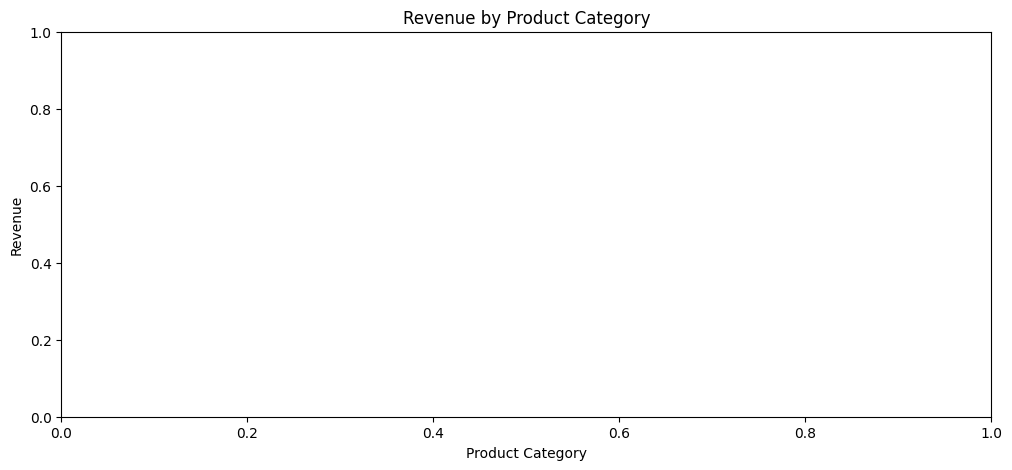

In [12]:
#Top products Category by revenue

category_revenue = df.groupby('Product Category')['Total Amount'].sum()
print(category_revenue)
plt.bar(category_revenue.index, category_revenue.values, color='purple')
plt.figure(figsize=(12,5))
plt.xlabel("Product Category")
plt.ylabel('Revenue')
plt.title("Revenue by Product Category")
plt.tight_layout
plt.show()

We have our top product category by revenue as Electronics boasting a total revenue of over 150,000, followed by clothing and beauty

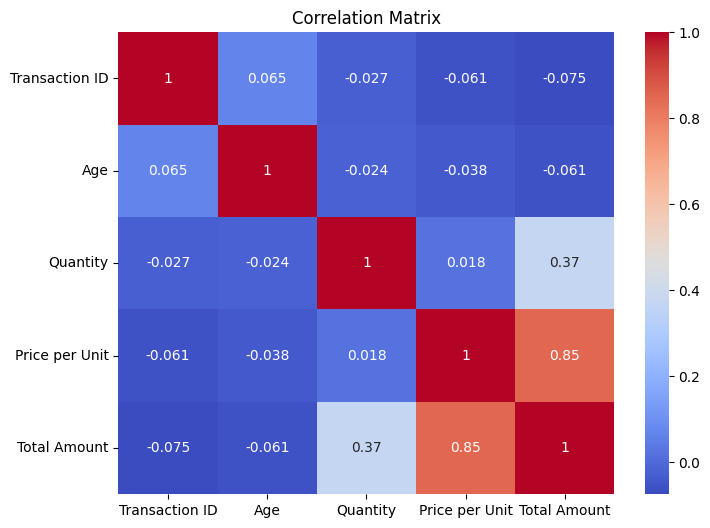

In [13]:
#Correlation matrix heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Transaction ID','Age','Quantity','Price per Unit','Total Amount']].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

The correlation heatmap shows that most numerical features have little to no linear relationship with one another. The strongest positive correlation is between Price per Unit and Total Amount(0.85), indicating that higher unit prices generally lead to higher transaction values. Quantity also has a moderate positive correlation with Total Amount(0.37). 

/tmp/ipykernel_16/1659154163.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_spend = df.groupby(['Age Group', 'Gender'])['Total Amount'].mean().reset_index()


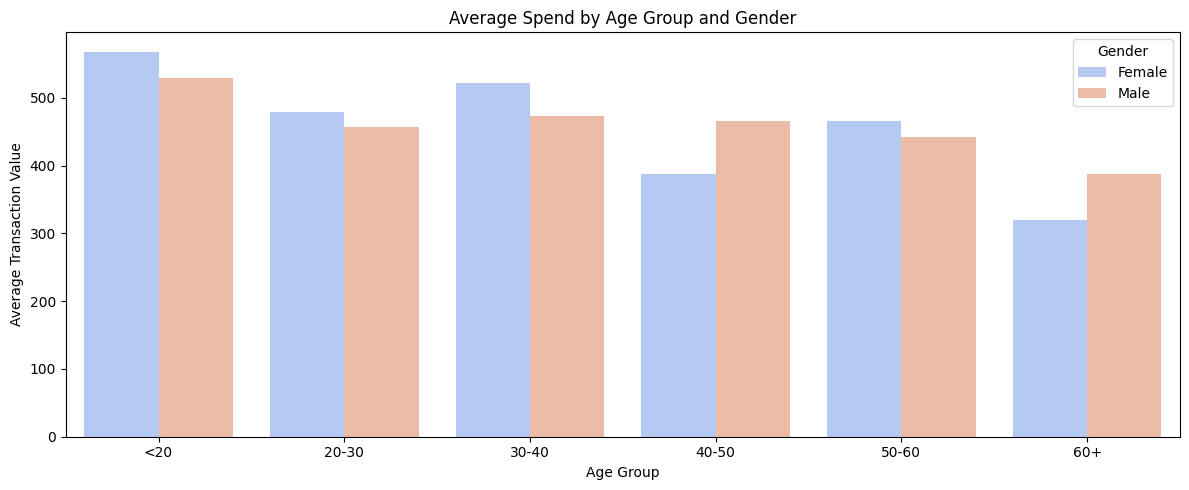

In [14]:
plt.figure(figsize=(12,5))
age_gender_spend = df.groupby(['Age Group', 'Gender'])['Total Amount'].mean().reset_index()
sns.barplot(
    data=age_gender_spend,
    x='Age Group',
    y='Total Amount',
    hue='Gender',
    palette='coolwarm'
)
plt.title("Average Spend by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel('Average Transaction Value')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

Average spending varies across age groups, with younger customers (<20) recording the highest average transaction values. Spending patterns between males and females are generally similar, although slight differnces exist in some age groups, particularly among customers aged 60 and above.

### Conclusion & Business Recommendations

## Summary of Key Findings

This exploratory data analysis of 1,000 retail transactions revealed 
several meaningful patterns across time, customer demographics, product 
performance, and spending behaviour:

- The average customer is **41 years** old, spends **$135 per transaction**, 
  and purchases **4 units** on average. The high standard deviation of $599.99 
  confirms significant variability in customer spending — suggesting distinct 
  high-value and low-value customer segments exist.

- **Q4 was the strongest quarter** ($126,190 in revenue) while Q3 was the 
  weakest ($96,045). Monthly trends showed a strong January start, a mid-year 
  dip peaking at an all-time low in September, before recovering toward 
  year-end.

- **Female customers slightly dominate** (510 vs 490 male), and the 
  **40–50 age group** is the largest customer segment.

- **Electronics generates the highest revenue** ($150,000+) despite Clothing 
  being the most purchased category by units — confirming that Electronics 
  commands premium price points per transaction.

- **Price per Unit and Total Amount** share the strongest correlation (0.85), 
  confirming that pricing strategy is the primary driver of revenue per 
  transaction.

- **Younger customers (<20)** record the highest average transaction values 
  — a counterintuitive finding that warrants further investigation.

---

### Business Recommendations

**Recommendation 1: Launch a Q3 Recovery Campaign**
Q3 consistently recorded the lowest revenue ($96,045) with September 
hitting an all-time low. The business should introduce targeted promotional 
campaigns, seasonal discounts, or loyalty reward activations specifically 
in July–September to stimulate demand during this natural dip period. 
A mid-year sale event could help smooth revenue fluctuations across quarters.

**Recommendation 2: Prioritize Electronics Marketing Despite Clothing Volume**
While Clothing sells the most units, Electronics generates the highest 
revenue ($150,000+). Marketing budgets should be reallocated to promote 
Electronics more aggressively — particularly to the 40–50 age group who 
represent the largest customer segment and are likely to be working 
professionals with higher disposable income for premium purchases.

**Recommendation 3: Investigate and Leverage the <20 High-Spend Anomaly**
The finding that customers under 20 record the highest average transaction 
values is non-obvious and potentially very valuable. This could indicate 
gift purchases, parental spending, or a niche high-value youth segment. 
The business should investigate this group further through customer surveys 
or deeper segmentation analysis — and if confirmed, develop targeted 
campaigns to grow this demographic since they punch above their weight 
in spending value.